In [4]:
import pandas as pd #  pandas
import numpy as np # numpy
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint para visualización metadatos
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import seaborn as sns # seaborn
import statsmodels.api as sm #statsmodels
from sklearn.model_selection import train_test_split # para dividir los datos en train y test
from sklearn.preprocessing import StandardScaler, LabelEncoder # para estandarizar los datos
from sklearn.linear_model import LogisticRegression # RL
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # informes de resultados
from sklearn.model_selection import GridSearchCV # para grid search
from sklearn.tree import DecisionTreeClassifier # DT
from sklearn.ensemble import RandomForestClassifier # RF
from sklearn.neighbors import KNeighborsClassifier #kNN
from sklearn.svm import SVC # SVC
from sklearn.naive_bayes import GaussianNB # GNß
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA
from sklearn.metrics import recall_score # recall
from sklearn.neural_network import MLPClassifier # MLP

# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

# Análisis de ML I

En este fichero se aplican los distintos algoritmos para clasificar pacientes (P) vs sanos (H).

Se pretende estudiar que clasificador es mejor y evaluar si la explicabilidad es similar en todos los casos.

### Preparación de los datos

- Se elimina la columna `ID` que no se necesita para el análisis.
- Se separan las variables predictoras (X) de la objetivo (Y)
- Se recodifica la variable objetivo `class`: paciente (P) a 0 y sano (H) a 1
- Y se dividen los datos (X e Y) en `train` 80% y `test` 20% aleatoriamente.

In [5]:
# Se elimina la columna ID
# X = df (sin 'ID' ni 'class'), axis = 1 para cols
X = df.drop(['ID', 'class'], axis = 1)

# Y contiene 'class'
Y = df['class']

# Se codficia paciente (P) -> 1 y sano (H) -> 0
le = LabelEncoder()
Y = le.fit_transform(Y)

# Se dividen los datos en 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Se revisa la correcta división de los datos
print(f"Datos de entrenamiento {len(X_train)}")
print(f"Datos test {len(X_test)}")

Datos de entrenamiento 139
Datos test 35


### Estandarización de los datos

Se estandarizan los datos, pues la regresión logística es sensible a la escala, para ello se emplea `StandarScaler()` (media 0, varianza 1).

In [6]:
# StandardScaler()
scaler = StandardScaler()

# Se ajusta la estandarización con X_train
X_train_scaled = scaler.fit_transform(X_train)

# Se aplica la transformación al test
X_test_scaled = scaler.transform(X_test)

## 1. Regresión logística (LR)

In [19]:
# Se crea el modelo
model_LR = LogisticRegression(max_iter=1000)

# Se entrena el modelo
model_LR.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred = model_LR.predict(X_test_scaled)

# Informe de clasificación
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred))

# Matriz de confusión
print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred))

# Matriz
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()

# Métricas 
# Sensibilidad (capacidad para detectar los pacientes correctamente)
sensitivity = tp / (tp + fn)

# Especificdad (capacidad para dectectar los sanos correctamente)
specificity = tn / (tn + fp)

print(f"Sensibilidad: {sensitivity:.2f}")
print(f"Especificidad: {specificity:.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        17
           1       0.68      0.72      0.70        18

    accuracy                           0.69        35
   macro avg       0.69      0.68      0.68        35
weighted avg       0.69      0.69      0.69        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.65


**Resumen:**
- F1-score = 0.67 para sanos (H) y 0.70 para pacientes (P).
- Accuracy = 0.69
- 11 sujetos sanos (H) han sido identificados como tal (TN).
- 13 pacientes (P) han sido identificados como tal (TP).
- 5 pacientes (P) han sido identificado como sanos (H) (FN).
- 6 sanos (H) han sido identificados como pacientes (P) (FP).

### 1.1. Mejora del modelo

Se mejora el modelo ajustando los hiperparametros.

In [20]:
"""
C 
min value 0.001 
max value 5 
step 0.005
"""
c_values = np.arange(0.001, 5.005, 0.005)

# Diccionario de parámetros
param_grid = {'C': c_values}

# Búsqueda con 5 pliegues de validación cruzada
grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000), 
    param_grid, 
    cv=5, 
    scoring='accuracy',
    verbose=1
)

# Se entrena el modelo
grid_search.fit(X_train_scaled, Y_train)

# Resultados
print(f"Mejor valor de C: {grid_search.best_params_['C']}")
print(f"Mejor Accuracy en CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
Y_pred_best = best_model.predict(X_test_scaled)

# Informe de clasificación
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_best))

# Matriz de confusión
print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_best))

# Matriz
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred_best).ravel()

# Métricas 
# Sensibilidad (capacidad para detectar los pacientes correctamente)
sensitivity = tp / (tp + fn)

# Especificdad (capacidad para dectectar los sanos correctamente)
specificity = tn / (tn + fp)

print(f"Sensibilidad: {sensitivity:.2f}")
print(f"Especificidad: {specificity:.2f}")

Fitting 5 folds for each of 1001 candidates, totalling 5005 fits
Mejor valor de C: 0.016
Mejor Accuracy en CV: 0.9066
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        17
           1       0.68      0.72      0.70        18

    accuracy                           0.69        35
   macro avg       0.69      0.68      0.68        35
weighted avg       0.69      0.69      0.69        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 5 13]]
Sensibilidad: 0.72
Especificidad: 0.65


**Resumen de la mejora del modelo:**
Los resultados obtenidos son los mismos que en el modelo anterior.
- F1-score = 0.67 para sanos (H) y 0.70 para pacientes (P).
- Accuracy = 0.69
- 11 sujetos sanos (H) han sido identificados como tal (TN).
- 13 pacientes (P) han sido identificados como tal (TP).
- 5 pacientes (P) han sido identificado como sanos (H) (FN).
- 6 sanos (H) han sido identificados como pacientes (P) (FP).
- Sensitivity = 0.72
- Specificity = 0.75

*En general, valores mas bajos que los obtenidos en el artículo Cilia et al. (2022).*

## 2. Decision Tree (DT)
Para DT y RF no es necesario usar los datos estandarizados, no obstanten se usan en ambos casos, para mantener el mismo dataser para los distintos algoritmos y minimizar las posibles diferencias entre ellos, para su posterior comparación.

In [10]:
# Se crea el modelo
tree_model = DecisionTreeClassifier(random_state=42) # random state para replicabilidad

# Se entrena el modelo
tree_model.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_dt = tree_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_dt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_dt))

# TP; TN; FP; FN
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(Y_test, Y_pred_dt).ravel()

sensitivity_dt = tp_dt / (tp_dt + fn_dt) # sensibilidad
print(f"Sensibilidad: {sensitivity_dt:.2f}")

specificity_dt = tn_dt / (tn_dt + fp_dt) # especificidad
print(f"Especificidad: {specificity_dt:.2f}")

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.78      0.82      0.80        17
           1       0.82      0.78      0.80        18

    accuracy                           0.80        35
   macro avg       0.80      0.80      0.80        35
weighted avg       0.80      0.80      0.80        35

--- MATRIZ DE CONFUSIÓN ---
[[14  3]
 [ 4 14]]
Sensibilidad: 0.78
Especificidad: 0.82


**Resumen:**
Accuracy = 0.80
F1 pacientes y sanos 0.80 respectivamente
Sensibilidad = 0.78
Especificidad = 0.82
- 14 sanos han sido identificados como tal (TN)
- 14 pacientes han sido identificados como tal (TP)
- 4 pacientes han sido identificados como sanos (FN)
- 3 sanos han sido identificados como pacientes (FP)

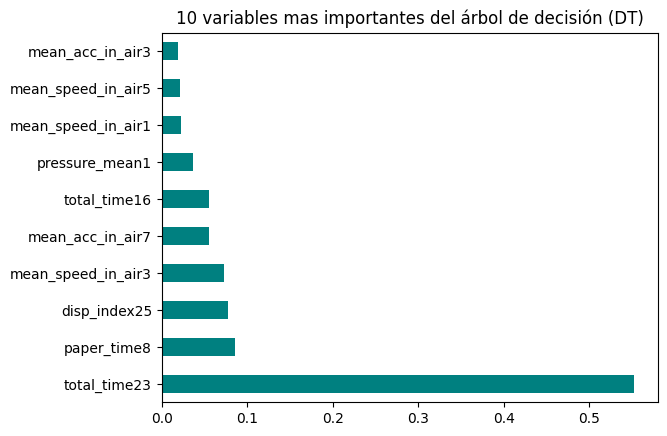

In [11]:
# Se extraen las importancias
importancias = pd.Series(tree_model.feature_importances_, index=X.columns)

# Se grafican los 10 mas importantes
importancias.nlargest(10).plot(kind="barh", color="teal")
plt.title("10 variables mas importantes del árbol de decisión (DT)") # título
plt.show()

### 2.1 Mejora del modelo

Se mejora el clasificador definiendo los hiperparámetros.

In [12]:
# max depth
max_depth_range = np.arange(2, 11, 1)

# min samples split
min_samples_split_range = np.arange(2, 6, 1)

# min samples leaf
min_samples_leaf_range = np.arange(2, 22, 2) 

param_grid_dt = {
    'max_depth': max_depth_range,
    'min_samples_split': min_samples_split_range,
    'min_samples_leaf': min_samples_leaf_range
}

# Buscador
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1
)

# Se entrena el modelo
grid_dt.fit(X_train_scaled, Y_train)

# Mejores resultados
print(f"Mejor combinación: {grid_dt.best_params_}")
print(f"Mejor accuracy en CV: {grid_dt.best_score_}")

# Mejor árbol
best_tree = grid_dt.best_estimator_

# Resultados
Y_pred_opt = best_tree.predict(X_test_scaled)

print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_opt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_opt))

# Sensibilidad y especificidad
tn_dt2, fp_dt2, fn_dt2, tp_dt2 = confusion_matrix(Y_test, Y_pred_opt).ravel()

print(f"Sensibilidad: {tp_dt2 / (tp_dt2 + fn_dt2):.2f}")
print(f"Especificidad: {tn_dt2 / (tn_dt2 + fp_dt2):.2f}")


Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Mejor combinación: {'max_depth': np.int64(2), 'min_samples_leaf': np.int64(18), 'min_samples_split': np.int64(2)}
Mejor accuracy en CV: 0.8637566137566137
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        17
           1       0.75      0.67      0.71        18

    accuracy                           0.71        35
   macro avg       0.72      0.72      0.71        35
weighted avg       0.72      0.71      0.71        35

--- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 6 12]]
Sensibilidad: 0.67
Especificidad: 0.76


In [ ]:
# max depth
max_depth_range = np.arange(2, 11, 1)

# min samples split
min_samples_split_range = np.arange(2, 6, 1)

# min samples leaf
min_samples_leaf_range = np.arange(2, 22, 2) 

max_leaf_nodes_range = np.arange(2, 21, 2)

criterion_options = ['gini', 'entropy']

param_grid_dt = {
    'criterion': criterion_options,
    'max_depth': max_depth_range,
    'min_samples_split': min_samples_split_range,
    'min_samples_leaf': min_samples_leaf_range,
    'max_leaf_nodes': max_leaf_nodes_range
}

# Buscador
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Se entrena el modelo
grid_dt.fit(X_train_scaled, Y_train)

# Mejores resultados
print(f"Mejor combinación: {grid_dt.best_params_}")
print(f"Mejor accuracy en CV: {grid_dt.best_score_}")

# Mejor árbol
best_tree = grid_dt.best_estimator_

# Resultados
Y_pred_opt = best_tree.predict(X_test_scaled)

print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_opt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_opt))

# Sensibilidad y especificidad
tn_dt2, fp_dt2, fn_dt2, tp_dt2 = confusion_matrix(Y_test, Y_pred_opt).ravel()

print(f"Sensibilidad: {tp_dt2 / (tp_dt2 + fn_dt2):.2f}")
print(f"Especificidad: {tn_dt2 / (tn_dt2 + fp_dt2):.2f}")


Fitting 5 folds for each of 7200 candidates, totalling 36000 fits


Con respecto al modelo anterior, el valor de accuracy, la sensibilidad y especifidad bajan. Se recomienda el modelo anterior.

## 3. Random Forest (RF)

In [19]:
# Modelo
rf_model = RandomForestClassifier(n_estimators=100, # 100 árboles
                                  random_state=42) # resultados reproducibles

# Se entrena el modelo
rf_model.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_rf = rf_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN: ---") # informe de clasificación
print(classification_report(Y_test, Y_pred_rf))

# Matriz de confusión
print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf))

# Sensibilidad y especificidad
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_rf / (tp_rf + fn_rf):.2f}")
print(f"Especificidad: {tn_rf / (tn_rf + fp_rf):.2f}")

 --- INFORME DE CLASIFICACIÓN: ---
              precision    recall  f1-score   support

           0       0.77      0.59      0.67        17
           1       0.68      0.83      0.75        18

    accuracy                           0.71        35
   macro avg       0.73      0.71      0.71        35
weighted avg       0.72      0.71      0.71        35

 --- MATRIZ DE CONFUSIÓN ---
[[10  7]
 [ 3 15]]
Sensibilidad: 0.83
Especificidad: 0.59


**Resumen:**
- Accuracy = 0.71
- F1-score para sanos (0) = 0.67
- F1-score para pacientes (1) = 0.75
- 10 sanos predichos como tal (TN).
- 15 pacientes predichos como tal (TP).
- 3 pacientes predichos como sanos (FN)
- 7 sanos predichos como pacientes (FP)
- Sensibilidad = 0.83
- Especificidad = 0.59, menor precisión a la hora de detectar a los sujetos sanos

### 3.1. Mejora del modelo

Se mejora el modelo definiendo los hiperparámetros, según Cilia et al. (2022).


In [20]:
# Se definen los hiperparámetros

rf2 = RandomForestClassifier(
    n_estimators=200, # 200 árboles
    max_depth=5, # profundidad máxima
    bootstrap=True,
    min_samples_split=2,
    min_samples_leaf=1
)

# Se entrena el modelo
rf2.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_rf2 = rf2.predict(X_test_scaled)

print("--- INFORME CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_rf2))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf2))

# Sensibilidad y especificidad
tn_rf2, fp_rf2, fn_rf2, tp_rf2 = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_rf2 / (tp_rf2 + fn_rf2):.2f}")
print(f"Especificidad: {tn_rf2 / (tn_rf2 + fp_rf2):.2f}")

--- INFORME CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        17
           1       0.80      0.89      0.84        18

    accuracy                           0.83        35
   macro avg       0.83      0.83      0.83        35
weighted avg       0.83      0.83      0.83        35

--- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 2 16]]
Sensibilidad: 0.83
Especificidad: 0.59


Los valores de sensibilidad y especificidad se mantienen, mientras que el valor de accuracy aumenta, por lo que se prefiere este modelo.

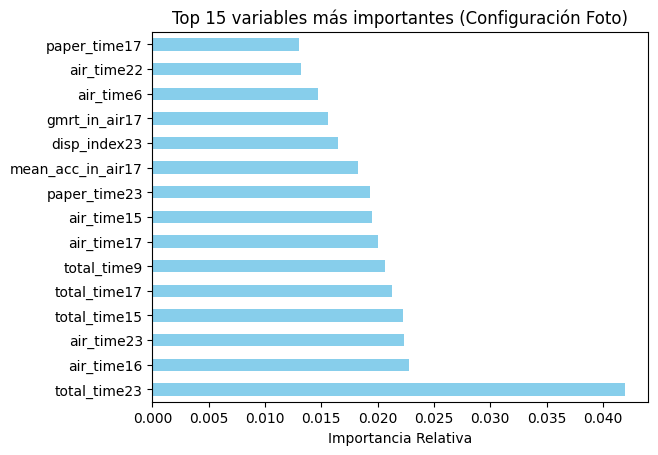

In [21]:
# Obtener importancia
importancias = pd.Series(rf2.feature_importances_, index=X.columns)

# Graficar las 15 más influyentes
importancias.nlargest(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 variables más importantes (Configuración Foto)')
plt.xlabel('Importancia Relativa')
plt.show()

## 4. k-Nearest Neighbors (kNN)

In [43]:
# Modelo con 5 vecinos
knn = KNeighborsClassifier(n_neighbors=5)

# Se entrena el modelo
knn.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_knn = knn.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_knn))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_knn))

# Sensibilidad y especificidad
tn_knn, fp_knn, fn_knn, tp_knn = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_knn / (tp_knn + fn_knn):.2f}")
print(f"Especificidad: {tn_knn / (tn_knn + fp_knn):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.58      0.88      0.70        17
           1       0.78      0.39      0.52        18

    accuracy                           0.63        35
   macro avg       0.68      0.64      0.61        35
weighted avg       0.68      0.63      0.61        35

--- MATRIZ DE CONFUSIÓN ---
[[15  2]
 [11  7]]
Sensibilidad: 0.83
Especificidad: 0.59


### 4.1. Mejora del modelo
Para la mejora del modelo se pueden emplear distintos valores de k, los resultados observados son similares.

## 5. Support Vector Machine (SVM)

In [59]:
# Modelo
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# Se entrena el modelo
svm_model.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_svm = svm_model.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_svm))

print("--- MATRIZ DE CLASIFICACIÓN ---")
print(confusion_matrix(Y_test, Y_pred_svm))

# Sensibilidad y especificidad
tn_svm, fp_svm, fn_svm, tp_svm = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_svm / (tp_svm + fn_svm):.2f}")
print(f"Especificidad: {tn_svm / (tn_svm + fp_svm):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        17
           1       0.78      0.78      0.78        18

    accuracy                           0.77        35
   macro avg       0.77      0.77      0.77        35
weighted avg       0.77      0.77      0.77        35

--- MATRIZ DE CLASIFICACIÓN ---
[[13  4]
 [ 4 14]]
Sensibilidad: 0.83
Especificidad: 0.59


### 5.1. Mejora del modelo

In [66]:
# Modelo
svm_ajustado = SVC(
    kernel='rbf', 
    C=1,           # Aumentamos C para penalizar más los errores
    gamma='scale',     # Ajustamos la influencia de cada dato
    probability=True,
    class_weight='balanced', # ¡Clave para reducir falsos negativos!
    random_state=42
)

# Se entrena el modelo
svm_ajustado.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_svm2 = svm_ajustado.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_svm2))

print("--- MATRIZ DE CLASIFICACIÓN ---")
print(confusion_matrix(Y_test, Y_pred_svm2))

# Sensibilidad y especificidad
tn_svm2, fp_svm2, fn_svm2, tp_svm2 = confusion_matrix(Y_test, Y_pred_svm2).ravel()

print(f"Sensibilidad: {tp_svm2 / (tp_svm2 + fn_svm2):.2f}")
print(f"Especificidad: {tn_svm2 / (tn_svm2 + fp_svm2):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        17
           1       0.78      0.78      0.78        18

    accuracy                           0.77        35
   macro avg       0.77      0.77      0.77        35
weighted avg       0.77      0.77      0.77        35

--- MATRIZ DE CLASIFICACIÓN ---
[[13  4]
 [ 4 14]]
Sensibilidad: 0.78
Especificidad: 0.76


## 6. Gaussian Naive Bayes

In [6]:
# Modelo
gnb = GaussianNB()

# Se entrena el modelo
gnb.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_gnb = gnb.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_gnb))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_gnb))

# Sensibilidad y especificidad
tn_gnb, fp_gnb, fn_gnb, tp_gnb = confusion_matrix(Y_test, Y_pred_gnb).ravel()

print(f"Sensibilidad: {tp_gnb / (tp_gnb + fn_gnb):.2f}")
print(f"Especificidad: {tn_gnb / (tn_gnb + fp_gnb):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        17
           1       0.80      0.89      0.84        18

    accuracy                           0.83        35
   macro avg       0.83      0.83      0.83        35
weighted avg       0.83      0.83      0.83        35

 --- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.76


### 6.1. Mejora del modelo

In [8]:
# Se ajustan los hiperparametros
gnb_custom = GaussianNB(
    priors=[0.5,0.5],
    var_smoothing=1e-9
)

# Se entrena el modelo
gnb_custom.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_gnb2 = gnb_custom.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_gnb2))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_gnb2))

# Sensibilidad y especificidad
tn_gnb2, fp_gnb2, fn_gnb2, tp_gnb2 = confusion_matrix(Y_test, Y_pred_gnb2).ravel()

print(f"Sensibilidad: {tp_gnb2 / (tp_gnb2 + fn_gnb2):.2f}")
print(f"Especificidad: {tn_gnb2 / (tn_gnb2 + fp_gnb2):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        17
           1       0.80      0.89      0.84        18

    accuracy                           0.83        35
   macro avg       0.83      0.83      0.83        35
weighted avg       0.83      0.83      0.83        35

 --- MATRIZ DE CONFUSIÓN ---
[[13  4]
 [ 2 16]]
Sensibilidad: 0.89
Especificidad: 0.76


## 7. Linear discriminat analysis (LDA)

In [11]:
# Modelo
lda = LinearDiscriminantAnalysis()

# Se entrena el modelo
lda.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_lda = lda.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_lda))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_lda))

# Sensibilidad y especificidad
tn_lda, fp_lda, fn_lda, tp_lda = confusion_matrix(Y_test, Y_pred_lda).ravel()

print(f"Sensibilidad: {tp_lda / (tp_lda + fn_lda):.2f}")
print(f"Especificidad: {tn_lda / (tn_lda + fp_lda):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.61      0.65      0.63        17
           1       0.65      0.61      0.63        18

    accuracy                           0.63        35
   macro avg       0.63      0.63      0.63        35
weighted avg       0.63      0.63      0.63        35

 --- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 7 11]]
Sensibilidad: 0.61
Especificidad: 0.65


In [12]:
# Modelo
lda_svd = LinearDiscriminantAnalysis(solver='svd', store_covariance=False)

# Se entrena el modelo
lda_svd.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_lda2 = lda_svd.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_lda2))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_lda2))

# Sensibilidad y especificidad
tn_lda2, fp_lda2, fn_lda2, tp_lda2 = confusion_matrix(Y_test, Y_pred_lda2).ravel()

print(f"Sensibilidad: {tp_lda2 / (tp_lda2 + fn_lda2):.2f}")
print(f"Especificidad: {tn_lda2 / (tn_lda2 + fp_lda2):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.61      0.65      0.63        17
           1       0.65      0.61      0.63        18

    accuracy                           0.63        35
   macro avg       0.63      0.63      0.63        35
weighted avg       0.63      0.63      0.63        35

 --- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 7 11]]
Sensibilidad: 0.61
Especificidad: 0.65


## 8. Learning vector quantization (LVQ)

In [5]:
def entrenar_lvq(X, Y, n_prototipos_por_clase=1, learning_rate=0.01, epochs=50):
    clases = np.unique(Y)
    prototipos = []
    labels_prototipos = []

    for c in clases:
        X_clase = X[Y == c]
        # Fixed typo: choice instead of cnoice
        indices = np.random.choice(len(X_clase), n_prototipos_por_clase, replace=False)
        for idx in indices:
            prototipos.append(X_clase[idx])
            labels_prototipos.append(c)

    # Convert to numpy array for vector operations
    prototipos = np.array(prototipos)
    
    for epoch in range(epochs): # Fixed parameter name
        for i in range(len(X)):
            x_i = X[i]
            y_i = Y[i]

            # Use "prototipos" consistently
            distancias = np.linalg.norm(prototipos - x_i, axis=1)
            ganador_idx = np.argmin(distancias)

            if labels_prototipos[ganador_idx] == y_i:
                prototipos[ganador_idx] += learning_rate * (x_i - prototipos[ganador_idx])
            else:
                prototipos[ganador_idx] -= learning_rate * (x_i - prototipos[ganador_idx])

        learning_rate *= 0.95

    return prototipos, labels_prototipos

def predecir_lvq(X, prototipos, labels_prototipos):
    predicciones = []
    for x_i in X:
        distancias = np.linalg.norm(prototipos - x_i, axis=1)
        ganador_idx = np.argmin(distancias)
        predicciones.append(labels_prototipos[ganador_idx])
    return np.array(predicciones)


# Se ejecuta con los datos escalados
prototipos, labels_p = entrenar_lvq(X_train_scaled, Y_train, n_prototipos_por_clase=2, epochs=100)

# Se realizan las predicciones
Y_pred_lvq = predecir_lvq(X_test_scaled, prototipos, labels_p)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_lvq))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_lvq))

# Sensibilidad y especificidad
tn_lvq, fp_lvq, fn_lvq, tp_lvq = confusion_matrix(Y_test, Y_pred_lvq).ravel()

print(f"Sensibilidad: {tp_lvq / (tp_lvq + fn_lvq):.2f}")
print(f"Especificidad: {tn_lvq / (tn_lvq + fp_lvq):.2f}")


--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        17
           1       0.69      0.61      0.65        18

    accuracy                           0.66        35
   macro avg       0.66      0.66      0.66        35
weighted avg       0.66      0.66      0.66        35

 --- MATRIZ DE CONFUSIÓN ---
[[12  5]
 [ 7 11]]
Sensibilidad: 0.61
Especificidad: 0.71


### 8.1. Mejora del modelo

In [9]:
# 1. Definición de las funciones (Debe ir antes del bucle)
def train_lvq_custom(X, y, n_prototypes, beta, max_iter):
    clases = np.unique(y)
    prototypes = []
    labels_proto = []
    
    # Inicializar prototipos aleatorios por clase
    for c in clases:
        X_c = X[y == c]
        if len(X_c) == 0: continue
        indices = np.random.choice(len(X_c), n_prototypes, replace=True)
        for idx in indices:
            prototypes.append(X_c[idx])
            labels_proto.append(c)
            
    prototypes = np.array(prototypes)
    labels_proto = np.array(labels_proto)
    alpha_initial = 0.01
    
    for i in range(max_iter):
        idx = np.random.randint(len(X))
        x_i, y_i = X[idx], y[idx]
        
        # Distancia euclidiana a los prototipos
        distances = np.linalg.norm(prototypes - x_i, axis=1)
        winner_idx = np.argmin(distances)
        
        alpha = alpha_initial * (1 - i / max_iter)
        
        # Aplicamos beta como factor de fuerza de actualización
        if labels_proto[winner_idx] == y_i:
            prototypes[winner_idx] += alpha * beta * (x_i - prototypes[winner_idx])
        else:
            prototypes[winner_idx] -= alpha * beta * (x_i - prototypes[winner_idx])
            
    return prototypes, labels_proto

def predict_lvq(X, prototypes, labels_proto):
    preds = []
    for x_i in X:
        distances = np.linalg.norm(prototypes - x_i, axis=1)
        preds.append(labels_proto[np.argmin(distances)])
    return np.array(preds)

# 2. Configuración de hiperparámetros (Tus rangos)
range_prototypes = range(1, 51, 5) # 1 a 50 step 5
range_beta = range(2, 51, 5)        # 2 a 50 step 5
max_iter = 2500

best_recall = -1
best_params = {}

print("Iniciando búsqueda de hiperparámetros...")

# 3. Bucle de búsqueda
for n_p in range_prototypes:
    for b in range_beta:
        # Entrenar
        protos, l_protos = train_lvq_custom(X_train_scaled, Y_train, n_p, b, max_iter)
        
        # Predecir
        y_pred = predict_lvq(X_test_scaled, protos, l_protos)
        
        # Evaluamos Recall de clase 1 (Pacientes) para evitar falsos negativos
        # También comprobamos que no clasifique todo como clase 1 (Recall clase 0 > 0)
        rec_p = recall_score(Y_test, y_pred, pos_label=1)
        rec_h = recall_score(Y_test, y_pred, pos_label=0)
        
        if rec_p > best_recall and rec_h > 0.1:
            best_recall = rec_p
            best_params = {'n_prototypes': n_p, 'beta': b}
            best_y_pred = y_pred

# 4. Resultado Final
print(f"\n--- MEJORES PARÁMETROS ENCONTRADOS ---")
print(f"Prototypes por clase: {best_params['n_prototypes']}")
print(f"Beta: {best_params['beta']}")
print(f"\n--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, best_y_pred))
print("\n--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, best_y_pred))

Iniciando búsqueda de hiperparámetros...

--- MEJORES PARÁMETROS ENCONTRADOS ---
Prototypes por clase: 6
Beta: 32

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        17
           1       0.74      0.78      0.76        18

    accuracy                           0.74        35
   macro avg       0.74      0.74      0.74        35
weighted avg       0.74      0.74      0.74        35


--- MATRIZ DE CONFUSIÓN ---
[[12  5]
 [ 4 14]]


## 9. Multilayer Perceptron (MLP)

In [4]:
# Modelo
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    learning_rate_init=0.001
)

# Se entrena el modelo
mlp.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_mlp = mlp.predict(X_test_scaled)

# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_mlp))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_mlp))

# Sensibilidad y especificidad
tn_mlp, fp_mlp, fn_mlp, tp_mlp = confusion_matrix(Y_test, Y_pred_mlp).ravel()

print(f"Sensibilidad: {tp_mlp / (tp_mlp + fn_mlp):.2f}")
print(f"Especificidad: {tn_mlp / (tn_mlp + fp_mlp):.2f}")

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.71      0.67      0.69        18

    accuracy                           0.69        35
   macro avg       0.69      0.69      0.69        35
weighted avg       0.69      0.69      0.69        35

 --- MATRIZ DE CONFUSIÓN ---
[[12  5]
 [ 6 12]]
Sensibilidad: 0.67
Especificidad: 0.71


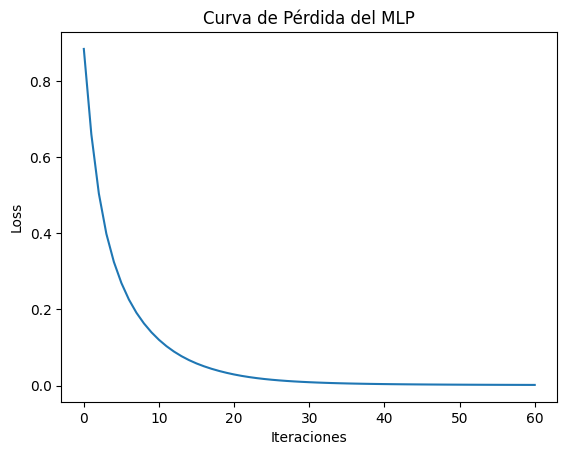

In [5]:
# Curva de pérdida
plt.plot(mlp.loss_curve_)
plt.title('Curva de Pérdida del MLP')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.show()

### 9.1. Mejora del modelo

In [8]:
# Espacio de búsqueda
param_grid= {
    'activation': ['relu', 'logistic', 'tanh'],
    'hidden_layer_sizes': [(i,) for i in range(8, 21)],
    'learning_rate_init': np.arange(0.05, 0.45, 0.05),
    'alpha': [0.0001]
}

# Búsqueda con F1
mlp2 = MLPClassifier(max_iter=1000, random_state=42)
grid_search = GridSearchCV(mlp2, param_grid, cv=5, scoring='f1', n_jobs=-1)

# Se entrena
grid_search.fit(X_train_scaled, Y_train)

# Mejores resultados
print(f"Mejores parámetros: {grid_search.best_params_}")

best_estimator = grid_search.best_estimator_
Y_pred_mlp2 = best_estimator.predict(X_test_scaled)


# Resultados
print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_mlp2))

print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_mlp2))

# Sensibilidad y especificidad
tn_mlp2, fp_mlp2, fn_mlp2, tp_mlp2 = confusion_matrix(Y_test, Y_pred_mlp2).ravel()

print(f"Sensibilidad: {tp_mlp2 / (tp_mlp2 + fn_mlp2):.2f}")
print(f"Especificidad: {tn_mlp2 / (tn_mlp2 + fp_mlp2):.2f}")

Mejores parámetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (18,), 'learning_rate_init': np.float64(0.3)}
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.68      0.88      0.77        17
           1       0.85      0.61      0.71        18

    accuracy                           0.74        35
   macro avg       0.76      0.75      0.74        35
weighted avg       0.77      0.74      0.74        35

 --- MATRIZ DE CONFUSIÓN ---
[[15  2]
 [ 7 11]]
Sensibilidad: 0.61
Especificidad: 0.88
